# Minimize a nonlinear function of one variable with no constraints

Do imports.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import sympy as sym

Define and plot the function

$$ f(x) = (x^4 / 4) - (4 x^3 / 3) + (3 x^2 / 2). $$

This function has a local maximum at $x=0$, a local minimum at $x=-1$, and a global minimum at $x=3$.

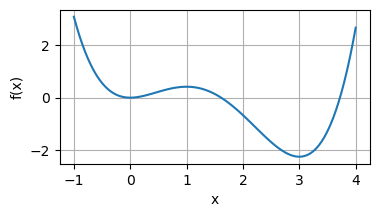

In [2]:
# Coefficients
c1 = 1 / 4
c2 = - 4 / 3
c3 = 3 / 2

# Variables
x = sym.symbols('x')

# Function (symbolic)
f_sym = sym.nsimplify(c1 * x**4 + c2 * x**3 + c3 * x**2)

# Function (numeric)
f = sym.lambdify(x, f_sym)

# Plot
xs = np.linspace(-1., 4., 100)
fs = f(xs)
fig, ax = plt.subplots(1, 1, figsize=(4, 2))
ax.plot(xs, fs)
ax.grid()
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
plt.show()

Define functions that compute the first and second derivative of $f(x)$ with respect to $x$.

In [3]:
# First derivative
f_x_sym = f_sym.diff(x)
f_x = sym.lambdify(x, f_x_sym)

# Second derivative
f_xx_sym = f_x_sym.diff(x)
f_xx = sym.lambdify(x, f_xx_sym)

# Display both first and second derivative
display(Markdown(r'$\dfrac{\partial f}{\partial x}' + f' = {sym.latex(f_x_sym)}$'))
display(Markdown(r'$\dfrac{\partial^2 f}{\partial x^2}' + f' = {sym.latex(f_xx_sym)}$'))

$\dfrac{\partial f}{\partial x} = x^{3} - 4 x^{2} + 3 x$

$\dfrac{\partial^2 f}{\partial x^2} = 3 x^{2} - 8 x + 3$

Show two interpretations of the Newton step, starting from $x_0$.

---

If we approximate $\partial f(x) / \partial x$ to first order as

$$ \dfrac{\partial f(x)}{\partial x} \approx \dfrac{\partial f(x_0)}{\partial x} + \dfrac{\partial f(x_0)^2}{\partial x^2} (x - x_0) $$

then the root satisfies

$$ x - x_0 = - \left( \dfrac{\partial f(x_0)^2}{\partial x^2} \right)^{-1} \dfrac{\partial f(x_0)}{\partial x} $$

as long as

$$ \dfrac{\partial f(x_0)^2}{\partial x^2} \neq 0. $$

---

If we approximate $f(x)$ to second order as

$$ f(x) \approx f(x_0) + \dfrac{\partial f(x_0)}{\partial x} (x - x_0) + \dfrac{1}{2}\dfrac{\partial f(x_0)^2}{\partial x^2} (x - x_0)^2 $$

then the minimum satisfies

$$ x - x_0 = - \left( \dfrac{\partial f(x_0)^2}{\partial x^2} \right)^{-1} \dfrac{\partial f(x_0)}{\partial x} $$

as long as

$$ \dfrac{\partial f(x_0)^2}{\partial x^2} > 0. $$

---

These equivalent results give us an update rule:

$$x_{k + 1} = x_k - \left( \dfrac{\partial f(x_k)^2}{\partial x^2} \right)^{-1} \dfrac{\partial f(x_k)}{\partial x}. $$

x_0 = 3.50
x_1 = 3.13


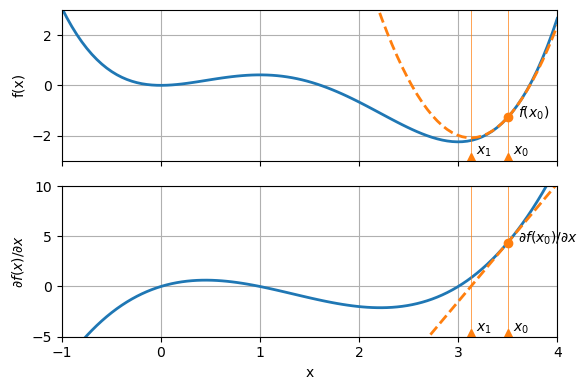

In [4]:
# Guess at minimum
x0 = 3.5
print(f'x_0 = {x0:4.2f}')

# New guess at minimum
x1 = x0 - f_x(x0) / f_xx(x0)
print(f'x_1 = {x1:4.2f}')

# Create figure
fig, (ax_f, ax_f_x) = plt.subplots(2, 1, figsize=(6, 4), tight_layout=True, sharex=True)

# Plot function and its quadratic approximation
x_lim = [-1., 4.]
xs = np.linspace(*x_lim, 100)
fs = f(xs)
ax_f.plot(xs, fs, linewidth=2)
a_x = 0.05
a_y = 0.25
f_lim = [-3, 3]
f_approx = f(x0) + f_x(x0) * (xs - x0) + (1 / 2) * f_xx(x0) * (xs - x0)**2
ax_f.plot(xs, f_approx, '--', linewidth=2)
ax_f.plot(x0, f(x0), '.', color='C1', markersize=12)
ax_f.text(x0 + 2 * a_x, f(x0), r'$f(x_0)$')
ax_f.plot(x0, f_lim[0], '^', color='C1', markersize=12)
ax_f.text(x0 + a_x, f_lim[0] + a_y, '$x_0$')
ax_f.plot([x0, x0], f_lim, color='C1', linewidth=0.5)
if (x1 > x_lim[0]) and (x1 < x_lim[1]):
    ax_f.plot(x1, f_lim[0], '^', color='C1', markersize=12)
    ax_f.text(x1 + a_x, f_lim[0] + a_y, '$x_1$')
    ax_f.plot([x1, x1], f_lim, color='C1', linewidth=0.5)

# Plot first derivative of function and its linear approximation
f_xs = f_x(xs)
ax_f_x.plot(xs, f_xs, linewidth=2)
a_x = 0.05
a_y = 0.5
f_x_lim = [-5, 10]
f_x_approx = f_x(x0) + f_xx(x0) * (xs - x0)
ax_f_x.plot(xs, f_x_approx, '--', linewidth=2)
ax_f_x.plot(x0, f_x(x0), '.', color='C1', markersize=12)
ax_f_x.text(x0 + 2 * a_x, f_x(x0), r'$\partial f(x_0) / \partial x$')
ax_f_x.plot(x0, f_x_lim[0], '^', color='C1', markersize=12)
ax_f_x.text(x0 + a_x, f_x_lim[0] + a_y, '$x_0$')
ax_f_x.plot([x0, x0], f_x_lim, color='C1', linewidth=0.5)
if (x1 > x_lim[0]) and (x1 < x_lim[1]):
    ax_f_x.plot(x1, f_x_lim[0], '^', color='C1', markersize=12)
    ax_f_x.text(x1 + a_x, f_x_lim[0] + a_y, '$x_1$')
    ax_f_x.plot([x1, x1], f_x_lim, color='C1', linewidth=0.5)

# Make plots look good
ax_f.grid()
ax_f.set_ylabel('f(x)')
ax_f.set_ylim(*f_lim)
ax_f_x.grid()
ax_f_x.set_xlabel('x')
ax_f_x.set_ylabel(r'$\partial f(x) / \partial x$')
ax_f_x.set_xlim(*x_lim)
ax_f_x.set_ylim(*f_x_lim)
plt.show()

Show convergence to a local minimum by repeated application of the Newton step.

  0 : x =  3.5000 : cost = -1.2760 : res =  4.37500000
  1 : x =  3.1277 : cost = -2.1976 : res =  0.84952275
  2 : x =  3.0117 : cost = -2.2496 : res =  0.07083392
  3 : x =  3.0001 : cost = -2.2500 : res =  0.00067354
  4 : x =  3.0000 : cost = -2.2500 : res =  0.00000006
  5 : x =  3.0000 : cost = -2.2500 : res =  0.00000000
success (converged at iteration 5)


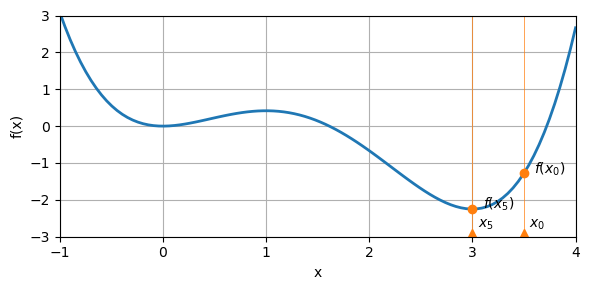

In [5]:
# Choose initial guess and compute cost and residual
x = 3.5
res = np.abs(f_x(x))
cost = f(x)

# Create log to keep track of convergence
log = {
    'x': [x],
    'res': [res],
    'cost': [cost],
}

# Choose parameters
max_iters = 50
tol = 1e-8

# Iterate
for i in range(max_iters):
    # Show progress
    print(f'{i:3d} : x = {x:7.4f} : cost = {cost:7.4f} : res = {res:11.8f}')

    # Check stopping condition (residual)
    if res < tol:
        print(f'success (converged at iteration {i})')
        break

    # Update guess
    x = x - f_x(x) / f_xx(x)
    res = np.abs(f_x(x))
    cost = f(x)

    # Update log
    log['x'].append(x)
    log['res'].append(res)
    log['cost'].append(cost)

# Plot results
fig, ax_f = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
x_lim = [-1., 4.]
xs = np.linspace(*x_lim, 100)
fs = f(xs)
ax_f.plot(xs, fs, linewidth=2)
x0 = log['x'][0]
i0 = 0
xN = log['x'][-1]
iN = len(log['x']) - 1
a_x = 0.05
a_y = 0.25
f_lim = [-3, 3]
ax_f.plot(x0, f(x0), '.', color='C1', markersize=12)
ax_f.text(x0 + 2 * a_x, f(x0), rf'$f(x_{i0})$')
ax_f.plot(x0, f_lim[0], '^', color='C1', markersize=12)
ax_f.text(x0 + a_x, f_lim[0] + a_y, rf'$x_{i0}$')
ax_f.plot([x0, x0], f_lim, color='C1', linewidth=0.5)
ax_f.plot(xN, f(xN), '.', color='C1', markersize=12)
ax_f.text(xN + 2 * a_x, f(xN), rf'$f(x_{iN})$')
ax_f.plot(xN, f_lim[0], '^', color='C1', markersize=12)
ax_f.text(xN + a_x, f_lim[0] + a_y, rf'$x_{iN}$')
ax_f.plot([xN, xN], f_lim, color='C1', linewidth=0.5)
ax_f.grid()
ax_f.set_ylabel('f(x)')
ax_f.set_xlim(*x_lim)
ax_f.set_ylim(*f_lim)
ax_f.set_xlabel('x')
plt.show()

For some $x_0$, the approximations can be unhelpful and the steps can be bad. Can you find an $x_0$ that is not already a local minimum for which...
* the step has zero length (i.e., makes no progress)?
* the step is in the wrong direction (i.e., takes us toward a local maximum)?
* the step is very large (i.e., significantly overshoots a local minimum and perhaps also significantly increases the cost)?

x_0 = 1.50
x_1 = 1.00


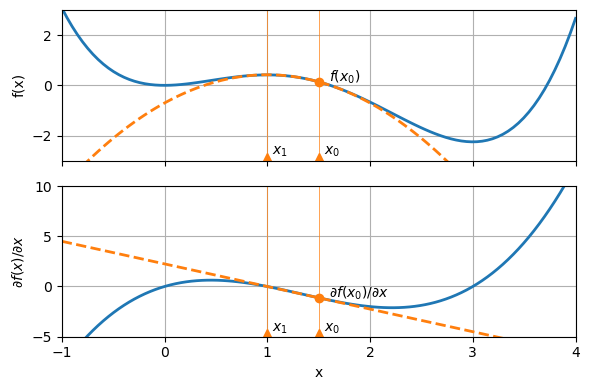

In [11]:
# Guess at minimum
x0 = 1.5
print(f'x_0 = {x0:4.2f}')

# New guess at minimum
x1 = x0 - f_x(x0) / f_xx(x0)
print(f'x_1 = {x1:4.2f}')

# Create figure
fig, (ax_f, ax_f_x) = plt.subplots(2, 1, figsize=(6, 4), tight_layout=True, sharex=True)

# Plot function and its quadratic approximation
x_lim = [-1., 4.]
xs = np.linspace(*x_lim, 100)
fs = f(xs)
ax_f.plot(xs, fs, linewidth=2)
a_x = 0.05
a_y = 0.25
f_lim = [-3, 3]
f_approx = f(x0) + f_x(x0) * (xs - x0) + (1 / 2) * f_xx(x0) * (xs - x0)**2
ax_f.plot(xs, f_approx, '--', linewidth=2)
ax_f.plot(x0, f(x0), '.', color='C1', markersize=12)
ax_f.text(x0 + 2 * a_x, f(x0), r'$f(x_0)$')
ax_f.plot(x0, f_lim[0], '^', color='C1', markersize=12)
ax_f.text(x0 + a_x, f_lim[0] + a_y, '$x_0$')
ax_f.plot([x0, x0], f_lim, color='C1', linewidth=0.5)
if (x1 > x_lim[0]) and (x1 < x_lim[1]):
    ax_f.plot(x1, f_lim[0], '^', color='C1', markersize=12)
    ax_f.text(x1 + a_x, f_lim[0] + a_y, '$x_1$')
    ax_f.plot([x1, x1], f_lim, color='C1', linewidth=0.5)

# Plot first derivative of function and its linear approximation
f_xs = f_x(xs)
ax_f_x.plot(xs, f_xs, linewidth=2)
a_x = 0.05
a_y = 0.5
f_x_lim = [-5, 10]
f_x_approx = f_x(x0) + f_xx(x0) * (xs - x0)
ax_f_x.plot(xs, f_x_approx, '--', linewidth=2)
ax_f_x.plot(x0, f_x(x0), '.', color='C1', markersize=12)
ax_f_x.text(x0 + 2 * a_x, f_x(x0), r'$\partial f(x_0) / \partial x$')
ax_f_x.plot(x0, f_x_lim[0], '^', color='C1', markersize=12)
ax_f_x.text(x0 + a_x, f_x_lim[0] + a_y, '$x_0$')
ax_f_x.plot([x0, x0], f_x_lim, color='C1', linewidth=0.5)
if (x1 > x_lim[0]) and (x1 < x_lim[1]):
    ax_f_x.plot(x1, f_x_lim[0], '^', color='C1', markersize=12)
    ax_f_x.text(x1 + a_x, f_x_lim[0] + a_y, '$x_1$')
    ax_f_x.plot([x1, x1], f_x_lim, color='C1', linewidth=0.5)

# Make plots look good
ax_f.grid()
ax_f.set_ylabel('f(x)')
ax_f.set_ylim(*f_lim)
ax_f_x.grid()
ax_f_x.set_xlabel('x')
ax_f_x.set_ylabel(r'$\partial f(x) / \partial x$')
ax_f_x.set_xlim(*x_lim)
ax_f_x.set_ylim(*f_x_lim)
plt.show()

##### The step produced by our update rule

Here is our update rule:

$$ x_{k+1} = x_k - \left( \dfrac{\partial f(x_k)^2}{\partial x^2} \right)^{-1} \dfrac{\partial f(x_k)}{\partial x}. $$

Equivalently, we can write

$$ x_{k+1} = x_k + p_k $$

where

$$ p_k = - \left( \dfrac{\partial f(x_k)^2}{\partial x^2} \right)^{-1} \dfrac{\partial f(x_k)}{\partial x} $$

is the step (i.e., the difference between the new guess and the old guess of the minimizer $x^\ast$).

##### What to do when the step is in the wrong direction

We saw that it is important to take a different step when

$$ \dfrac{\partial f(x_k)^2}{\partial x^2} \leq 0. $$

One option is to take a step in the direction of steepest descent (i.e., a gradient descent step instead of a Newton step):

$$ p_k = - \dfrac{\partial f(x_k)}{\partial x}. $$

This satisfies

$$ \dfrac{\partial f(x_k)}{\partial x} \neq 0, $$

in other words, that is not already at a local minimum, a local maximum, or an inflection point (the latter two cases are unlikely to occur — options include checking sufficient conditions or applying a random perturbation to $x_k$). Another option that may be more appropriate for higher-dimensional and constrained minimization problems is to "add regularization" — we will return to that later.

##### What to do when the step is too big

We also saw that, regardless of whether the step $p_k$ is chosen by Newton's method or by gradient descent, it may be important to scale this step as

$$ x_{k+1} = x_k + \alpha_k p_k $$

for some step size $\alpha_k \in (0, 1]$. One option is to choose an $\alpha_k$ that provides a *sufficient decrease* in the cost as measured by

$$f(x_k + \alpha_k p_k) - f(x_k) \leq c \alpha_k \dfrac{\partial f(x_k)}{\partial x} p_k $$

for some constant $c \in [0, 1]$. This inequality is called the *Armijo condition*. The idea is that

$$ \alpha_k \dfrac{\partial f(x_k)}{\partial x} p_k $$

is the amount that a first-order (linear) approximation to $f$ at $x_k$ would predict the cost to be reduced by taking a step of length $\alpha_k$ in the direction $p_k$, so we are choosing to accept any $\alpha_k$ that reduces the cost by at least a factor of $c$ relative to that prediction. If $c=0$, then this condition simply means that we accept any step size that decreases the cost even a little bit:

$$f(x_k + \alpha_k p_k) \leq f(x_k). $$

A common way to find an $\alpha_k$ satisfying the Armijo condition is by **backtracking line search** — start with $\alpha_k = 1$ and reduce $\alpha_k$ by a factor of $\rho \in (0, 1)$ at each iteration until the condition holds (or until you reach some maximum number of iterations and declare failure by no progress).

##### Typical parameter values

A common choice of $c$ is something close to 0, for example $c = 10^{-4}$. A common choice of $\rho$ is something closer to 1, for example $\rho = 0.5$ or $\rho = 0.9$. The maximum number of iterations you allow for backtracking line search depends on the choice of $\rho$ and on how small a step size $\alpha_k$ you would like to consider. For $\rho = 0.5$, it would take

$$ \left\lceil \dfrac{\log 0.5}{\log 0.001} \right\rceil = 10 $$

iterations before $\alpha_k < 0.001$, while for $\rho = 0.9$ it would take

$$ \left\lceil \dfrac{\log 0.9}{\log 0.001} \right\rceil = 66 $$

iterations to reach the same step size. These iterations are relatively cheap, but remember that they do require evaluating $f(x_k + \alpha_k p_k)$ at each iteration (i.e., at each candidate $\alpha_k$), so choosing a smaller value of $\rho$ (e.g., 0.5) and a corresondingly smaller number of maximum iterations (e.g., 10) is probably best.

##### Example

The following code cell shows a visualization of backtracking line search.

      x_0 =  2.00
f_xx(x_0) = -1.00  (negative)
      p_0 =  2.00  (by gradient descent)
        c =  0.20


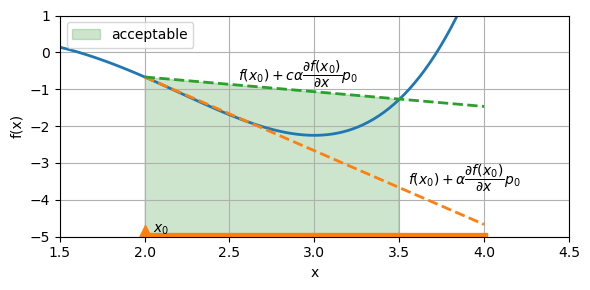

In [7]:
# Guess at minimum
x0 = 2.
print(f'      x_0 = {x0:5.2f}')

# Second derivative
print(f'f_xx(x_0) = {f_xx(x0):5.2f}  (negative)')

# Descent direction
p0 = - f_x(x0)
print(f'      p_0 = {p0:5.2f}  (by gradient descent)')

# Line search parameter
c = 0.2
print(f'        c = {c:5.2f}')

# Visualize line search
fig, ax_f = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
x_lim = [1.5, 4.5]
xs = np.linspace(*x_lim, 100)
fs = f(xs)
a_x = 0.05
a_y = 0.10
f_lim = [-5, 1]
alpha = np.linspace(0, 1, 100)
ax_f.fill_between(
    x0 + alpha * p0,
    np.ones_like(xs) * f_lim[0],
    f(x0) + c * f_x(x0) * (alpha * p0),
    where=f(x0 + alpha * p0) <= f(x0) + c * f_x(x0) * (alpha * p0),
    color='green',
    alpha=0.2,
    label='acceptable',
)
ax_f.plot(xs, fs, linewidth=2)
ax_f.plot(x0 + alpha * p0, f(x0) + f_x(x0) * (alpha * p0), '--', linewidth=2)
ax_f.text(x0 + 0.75 * p0 + a_x, f(x0) + f_x(x0) * (0.75 * p0) + a_y, r'$f(x_0) + \alpha \dfrac{\partial f(x_0)}{\partial x} p_0$')
ax_f.plot(x0 + alpha * p0, f(x0) + c * f_x(x0) * (alpha * p0), '--', linewidth=2)
ax_f.text(x0 + 0.25 * p0 + a_x, f(x0) + c * f_x(x0) * (0.25 * p0) + a_y, r'$f(x_0) + c \alpha \dfrac{\partial f(x_0)}{\partial x} p_0$')
ax_f.plot([x0, x0 + p0], [f_lim[0], f_lim[0]], 'C1', linewidth=6)
ax_f.text(x0 + a_x, f_lim[0] + a_y, '$x_0$')
ax_f.plot(x0, f_lim[0], '^', color='C1', markersize=18)
ax_f.grid()
ax_f.set_ylabel('f(x)')
ax_f.set_xlim(*x_lim)
ax_f.set_ylim(*f_lim)
ax_f.set_xlabel('x')
ax_f.legend()

plt.show()

Show convergence to a local minimum, this time with backtracking line search and with the descent direction computed differently when necessary.

  0 : x =  2.0000 : cost = -0.6667 : res =  2.00000000
  1 : x =  3.2800 : cost = -1.9767 : res =  2.09395200 : H = -1.00 : alpha = 0.640
  2 : x =  3.0482 : cost = -2.2428 : res =  0.30122075 : H =  9.04 : alpha = 1.000
  3 : x =  3.0018 : cost = -2.2500 : res =  0.01098457 : H =  6.49 : alpha = 1.000
  4 : x =  3.0000 : cost = -2.2500 : res =  0.00001667 : H =  6.02 : alpha = 1.000
  5 : x =  3.0000 : cost = -2.2500 : res =  0.00000000 : H =  6.00 : alpha = 1.000
success (converged at iteration 5)


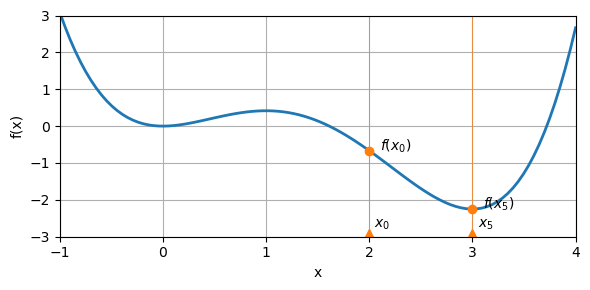

In [8]:
# Choose initial guess and compute cost and residual
x = 2.0
res = np.abs(f_x(x))
cost = f(x)

# Create log to keep track of convergence
log = {
    'x': [x],
    'res': [res],
    'cost': [cost],
}

# Choose parameters
max_iters = 50
max_inner_iters = 25
tol = 1e-8
c = 0.2
rho = 0.8
show_line_search = False

# Iterate
alpha = None
H = None
for i in range(max_iters):
    # Show progress
    H_str = f' : H = {H:5.2f}' if H is not None else ''
    alpha_str = f' : alpha = {alpha:4.3f}' if alpha is not None else ''
    print(f'{i:3d} : x = {x:7.4f} : cost = {cost:7.4f} : res = {res:11.8f}{H_str}{alpha_str}')

    # Check stopping condition (residual)
    if res < tol:
        if i == 0:
            print(f'success (initial guess satisfies necessary conditions for optimality)')
        else:
            print(f'success (converged at iteration {i})')
        break

    # Choose descent direction
    H = f_xx(x)
    if H > 0:
        # Newton step
        p = - f_x(x) / H
    else:
        # Gradient descent step
        p = - f_x(x)

    # Apply backtracking line search
    alpha = 1.
    no_progress = True
    for i_inner in range(max_inner_iters):
        if show_line_search:
            print(f' {i_inner:3d} : {alpha:5.3f} : {f(x + alpha * p):9.6f} : {c * alpha * f_x(x) * p:9.6f}')
        if f(x + alpha * p) <= f(x) + c * alpha * f_x(x) * p:
            no_progress = False
            break
        else:
            alpha *= rho

    # Check stopping condition (no progress)
    if no_progress:
        print(f'failure (no progress at iteration {i})')
        break

    # Update guess
    x = x + alpha * p
    res = np.abs(f_x(x))
    cost = f(x)

    # Update log
    log['x'].append(x)
    log['res'].append(res)
    log['cost'].append(cost)

# Plot results
fig, ax_f = plt.subplots(1, 1, figsize=(6, 3), tight_layout=True)
x_lim = [-1., 4.]
xs = np.linspace(*x_lim, 100)
fs = f(xs)
ax_f.plot(xs, fs, linewidth=2)
x0 = log['x'][0]
i0 = 0
xN = log['x'][-1]
iN = len(log['x']) - 1
a_x = 0.05
a_y = 0.25
f_lim = [-3, 3]
ax_f.plot(x0, f(x0), '.', color='C1', markersize=12)
ax_f.text(x0 + 2 * a_x, f(x0), rf'$f(x_{i0})$')
ax_f.plot(x0, f_lim[0], '^', color='C1', markersize=12)
ax_f.text(x0 + a_x, f_lim[0] + a_y, rf'$x_{i0}$')
ax_f.plot([x0, x0], f_lim, color='C1', linewidth=0.5)
ax_f.plot(xN, f(xN), '.', color='C1', markersize=12)
ax_f.text(xN + 2 * a_x, f(xN), rf'$f(x_{iN})$')
ax_f.plot(xN, f_lim[0], '^', color='C1', markersize=12)
ax_f.text(xN + a_x, f_lim[0] + a_y, rf'$x_{iN}$')
ax_f.plot([xN, xN], f_lim, color='C1', linewidth=0.5)
ax_f.grid()
ax_f.set_ylabel('f(x)')
ax_f.set_xlim(*x_lim)
ax_f.set_ylim(*f_lim)
ax_f.set_xlabel('x')
plt.show()